In [3]:
jsonl_path = "our_sec.jsonl"

import json
import os
import pandas as pd
import numpy as np

df = pd.read_json(jsonl_path, lines=True)
# drop duplicates
df = df.drop_duplicates(subset=["vuln_id"])
# remove nans from cwe_id
df = df[~df["cwe_id"].isna()]
# remove nans from cve_id
df = df[~df["score"].isna()]
# osv
df = df[df["dataset"] == "osv"]

In [4]:
df

,vuln_id,cwe_id,score,chain,dataset,summary,published_date,chain_len,project,commit_href,...,last_fix_commit,chain_ord_pos,commit_datetime,message,author,comments,stats,files,prior_version,after_version
0,GHSA-2363-cqg2-863c,{'CWE-611'},7.5,{'https://github.com/hunterhacker/jdom/commit/...,osv,XML External Entity (XXE) Injection in JDOM An...,2021-07-27,1,https://github.com/hunterhacker/jdom,https://github.com/hunterhacker/jdom/commit/dd...,...,dd4f3c2fc7893edd914954c73eb577f925a7d361,1,"07/02/2021, 03:42:05",Addresses #189 - synchronizes external entity ...,Rolf Lear,None,"{'additions': 6, 'deletions': 0, 'total': 6}",{'core/src/java/org/jdom2/input/SAXBuilder.jav...,OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) A...,OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) A...
1,GHSA-23cm-x6j7-6hq3,{'CWE-200'},5.9,{'https://github.com/matrix-org/matrix-js-sdk/...,osv,matrix-js-sdk can be tricked into disclosing E...,2021-09-14,1,https://github.com/matrix-org/matrix-js-sdk,https://github.com/matrix-org/matrix-js-sdk/co...,...,894c24880da0e1cc81818f51c0db80e3c9fb2be9,1,"09/13/2021, 11:34:48",Verify target device key on reshare,RiotRobot,None,"{'additions': 29, 'deletions': 9, 'total': 38}",{'src/crypto/algorithms/megolm.ts': {'addition...,interface IPayload extends Partial<IMessage> ...,interface IPayload extends Partial<IMessage> ...
2,GHSA-23f2-vgr6-fwv7,{'CWE-74'},0.0,{'https://github.com/librenms/librenms/commit/...,osv,Command injection in librenms LibreNMS v22.3.0...,2022-06-03,1,https://github.com/librenms/librenms,https://github.com/librenms/librenms/commit/8b...,...,8b82341cb742e7bd4966964b399012f7ba017e0b,1,"04/21/2022, 02:32:36",Fix services command injection (#13932)\n\n* f...,Tony Murray,"{'com_1': {'author': 'bakerds', 'datetime': '0...","{'additions': 6, 'deletions': 1, 'total': 7}","{'includes/services.inc.php': {'additions': 6,...",use LibreNMS\Alert\AlertRules; use LibreNMS\C...,use LibreNMS\Alert\AlertRules; use LibreNMS\C...
3,GHSA-23fp-fmrv-f5px,{'CWE-400'},4.9,{'https://github.com/strapi/strapi/commit/c0c1...,osv,Uncontrolled Resource Consumption in strapi A ...,2021-12-10,1,https://github.com/strapi/strapi,https://github.com/strapi/strapi/commit/c0c191...,...,c0c191c08f05fe10d7a6b1bf9475c1a651a89362,1,"01/07/2020, 13:15:16",chore(admin): Improve plugin name validator in...,Alexandre Bodin,None,"{'additions': 13, 'deletions': 2, 'total': 15}",{'packages/strapi-admin/controllers/Admin.js':...,const formatError = error => [ { messages: ...,const formatError = error => [ { messages: ...
4,GHSA-23hm-7w47-xw72,{'CWE-125'},8.1,{'https://github.com/tensorflow/tensorflow/com...,osv,Out of bounds read in Tensorflow ### Impact \n...,2022-02-09,1,https://github.com/tensorflow/tensorflow,https://github.com/tensorflow/tensorflow/commi...,...,23968a8bf65b009120c43b5ebcceaf52dbc9e943,1,"11/20/2021, 07:16:11",Fix out of bound access in DequantizeOp by add...,Isha Arkatkar,None,"{'additions': 5, 'deletions': 0, 'total': 5}",{'tensorflow/core/kernels/dequantize_op.cc': {...,class DequantizeOp : public OpKernel { co...,class DequantizeOp : public OpKernel { co...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,GHSA-xrr4-74mc-rpjc,{'CWE-59'},7.5,{'https://github.com/irmen/Pyro3/commit/554e09...,osv,Pyro mishandles pid files in temporary directo...,2018-08-21,1,https://github.com/irmen/Pyro3,https://github.com/irmen/Pyro3/commit/554e095a...,...,554e095a62c4412c91f981e72fd34a936ac2bf1e,1,"09/01/2011, 13:32:40",changed pidfile location because of security v...,irmen,None,"{'additions': 7, 'deletions': 1, 'total': 8}","{'Pyro/ext/daemonizer.py': {'additions': 7, 'd...","class Daemonizer: """""" def __init__(se...","class Daemonizer: """""" def __init__(se..."
821,GHSA-xvjm-fvxx-q3hv,{'CWE-190'},2.5,{'https://github.com/tensorflow/tensorflow/com...,osv,CHECK-fail due to integer overflow ### Impact\...,2021-05-21,1,https://github.com/tensorflow/tensorflow,https://github.com/tensorflow/tensorflow/commi.

In [5]:
df.columns

Index(['vuln_id', 'cwe_id', 'score', 'chain', 'dataset', 'summary',
       'published_date', 'chain_len', 'project', 'commit_href', 'commit_sha',
       'patch', 'chain_ord', 'before_first_fix_commit', 'last_fix_commit',
       'chain_ord_pos', 'commit_datetime', 'message', 'author', 'comments',
       'stats', 'files', 'prior_version', 'after_version'],
      dtype='object')

In [6]:
# Save the DataFrame to a jsonl file
output_path = "our_sec_cleaned.jsonl"

with open(output_path, "w") as f:
    for record in df.to_dict(orient="records"):
        json.dump(record, f)
        f.write("\n")
    


Text(0, 0.5, 'Security Weakness (CWE)')

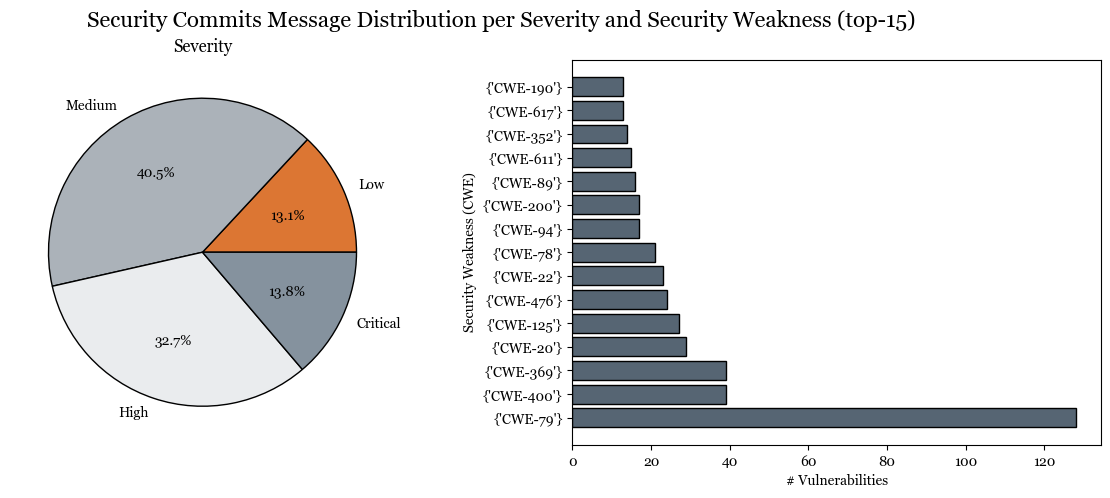

In [7]:
score = {'Low': 0, 'Medium': 0, 'High': 0, 'Critical': 0}
for sc in df.drop_duplicates(subset=['vuln_id'], keep="first")['score']:
    if sc >= 0.1 and sc <= 3.9:
        score['Low'] += 1
    elif sc >= 4.0 and sc <= 6.9:
        score['Medium'] += 1
    elif sc >= 7.0 and sc <= 8.9:
        score['High'] +=1 
    elif sc >= 9.0 and sc <= 10.0:
        score['Critical'] += 1

cwes_list = {}
for index, row in df.iterrows():
    cwe_id = row["cwe_id"]
    if cwe_id not in cwes_list:
        cwes_list[cwe_id] = 1
    else:
        cwes_list[cwe_id] += 1
df_sorted_cwes_list = pd.DataFrame(cwes_list.items(), columns=['cwe_id', 'count']).sort_values('count', ascending=False)
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Georgia"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Security Commits Message Distribution per Severity and Security Weakness (top-15)', size=16)

# score dist
ax1.pie(np.array(list(score.values())), 
        labels=list(score.keys()), 
        colors=['#DC7633', '#ABB2B9', '#EAECEE', '#85929E'],
        wedgeprops = {"edgecolor" : "black",
                      'linewidth': 1,
                      'antialiased': True}, 
        autopct='%.1f%%')
ax1.set_title('Severity')

# cwe dist
ax2.barh(list(df_sorted_cwes_list['cwe_id'].values)[0:15], 
        list(df_sorted_cwes_list['count'].values)[0:15],
        edgecolor='black',
        color='#566573')

ax2.set_xlabel("# Vulnerabilities")
ax2.set_ylabel("Security Weakness (CWE)")